In [ ]:
#| default_exp methods.visualization

In [ ]:
#| export
import numpy as np
from numpy.typing import NDArray
import matplotlib.pyplot as plt
import scipy.stats as stats
import networkx as nx

# Boxplot Summary

In [3]:
#| export

def simulation_boxplot_summary(data, 
                               param1_values, 
                               param2_values, 
                               title, 
                               ylabel, 
                               parameter_names = ['Paramter 1', 'Parameter 2'],
                               legend_loc = 2,
                               legend_cols = 3,
                               legend_fontsize = 12
                              ):
    '''
    data: 3D array, with simulation results. First two dimensions give value of a simulation parameter, third dimension gives the simulation number.
    '''


    
    A = np.shape(data)[0] #param1
    B = np.shape(data)[1] #param2
    C = np.shape(data)[2] #simulations
    # Define colors for B indices
    colors = plt.cm.viridis(np.linspace(0, 1, B))  # B distinct colors
    
    d = 3 #priming softmax index
    for b in range(B):
        box_data = [data[a, b, :] for a in range(A)]
        positions = np.arange(A) + (b - B / 2) * 0.1  # Adjust positions to avoid overlap
        plt.boxplot(box_data, positions=positions, widths=0.1, patch_artist=True, 
                    boxprops=dict(facecolor=colors[b], alpha=0.6), 
                    medianprops=dict(color='black'))
        # Calculate and add 95% credible interval error bars
        for a in range(A):
            mean_val = np.mean(data[a, b, :])
            ci_low, ci_high = stats.t.interval(0.95, df=C-1, loc=mean_val, scale=stats.sem(data[a, b, :]))
            plt.errorbar(positions[a], mean_val, yerr=[[mean_val - ci_low], [ci_high - mean_val]], fmt='o', color='black')
    
    # Create legend
    legend_patches = [plt.Line2D([0], [0], color=colors[b], lw=4, label=f'{parameter_names[1]}={param2_values[b]}') for b in range(B)]
    plt.legend(handles=legend_patches, loc = legend_loc, ncol = legend_cols, fontsize = legend_fontsize)
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xlabel(parameter_names[0])
    plt.xticks(range(A), labels=[f"{param1_values[a]}" for a in range(A)])

In [ ]:
#| export
from typing import Any
import matplotlib.pyplot as plt
from matplotlib.axes import Axes
import numpy as np

def plot_heatmap(matrix: NDArray[np.float_], 
                 title: str ="Expectation of Memory Traces",    
                 xlabel: str ="Trace", 
                 ylabel: str ="Time Step", 
                 color:str ="Blues", 
                 extent:tuple[float,float,float,float] | None = None,           #sets limits of axis coordinats: [left, right, bottom, top]
                 figsize:tuple[float, float] =(8, 6),
                 xticks:list[float] | None = None,
                 xtick_labels:list[str] | None = None,
                 yticks:list[float] | None = None,
                 ytick_labels:list[str] | None = None,
                 ax: Axes|None =None,                                           #optional plt axis to draw plot on
                 vmin:float|None=None,                                          #minimum for heatmap colorscale
                 vmax:float|None=None,                                          #maximum for heatmap colorscale
                 label_scale:float=1.0,                                         #multiplier for label sizes
                 colorbar_kwargs: dict[str,Any] | None ={},                     #arguments to pass to colorbar function
                ):
    """
    Plots a heatmap of the given matrix using the intensity of a single color,
    allowing arbitrary colorbar arguments to be passed in as a dictionary.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
        show = True
    else:
        fig = ax.figure
        show = False  # Don't show if plotting to existing axis

    nrows, ncols = matrix.shape

    # Set extent so each pixel spans [i, i+1] in axis coords
    if extent is None:
        extent = (0, ncols, nrows, 0)  # left, right, bottom, top

    im = ax.imshow(matrix, cmap=plt.colormaps.get_cmap(color), 
                   aspect='auto', extent=extent, vmin=vmin, vmax=vmax)

    tick_fontsize = 10 * label_scale
    label_fontsize = 12 * label_scale
    title_fontsize = 14 * label_scale
    
    ax.set_title(title, fontsize=title_fontsize)
    ax.set_xlabel(xlabel, fontsize=label_fontsize)
    ax.set_ylabel(ylabel, fontsize=label_fontsize)
    ax.invert_yaxis()

    # Default xticks at centers
    if xticks is None:
        xticks = np.arange(ncols)
        ax.set_xticks(xticks + 0.5)
        if xtick_labels is None:
            xtick_labels = [str(i+1) for i in xticks]
        ax.set_xticklabels(xtick_labels, fontsize=tick_fontsize)
    else:
        ax.set_xticks(xticks)
        if xtick_labels is not None:
            ax.set_xticklabels(xtick_labels, fontsize=tick_fontsize)

    # Default yticks at centers
    if yticks is None:
        yticks = np.arange(nrows)
        ax.set_yticks(yticks + 0.5)
        if ytick_labels is None:
            ytick_labels = [str(i+1) for i in yticks]
        ax.set_yticklabels(ytick_labels, fontsize=tick_fontsize)
    else:
        ax.set_yticks(yticks)
        if ytick_labels is not None:
            ax.set_yticklabels(ytick_labels, fontsize=tick_fontsize)

    # Handle colorbar with passed arguments
    if colorbar_kwargs is not None:
        plt.colorbar(im, ax=ax, **colorbar_kwargs)

    if show:
        plt.show()
    else:
        return im

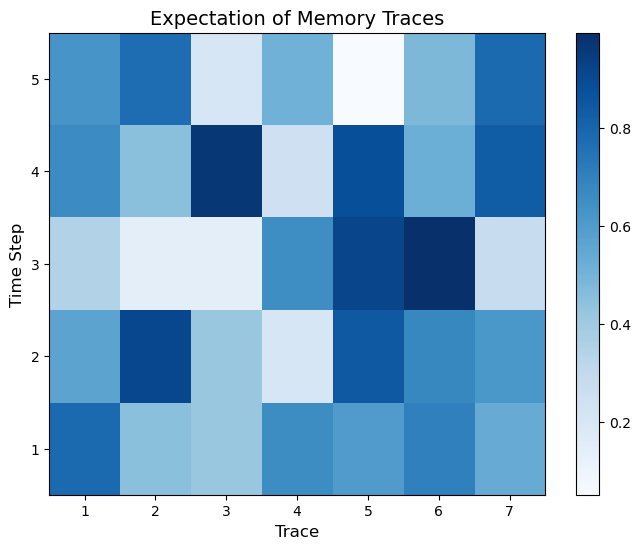

In [5]:
test_data = np.random.rand(5,7)
plot_heatmap(test_data)

In [7]:
#| export
def plot_circular_network(colors: list, highlight_index: int = None, ax = None, figwidth = 4, node_labels = None) -> None:
    """
    Plot a circular network where each node is colored according to the `colors` list,
    and the node at `highlight_index` has a bright green border.
    """
    if ax is None:
        fig = plt.figure(figsize=(figwidth,figwidth))
        ax = fig.add_subplot(111)
    else:
        plt.sca(ax)  # Set current axis
    num_nodes = len(colors)
    if highlight_index is not None:
        if highlight_index >= num_nodes or highlight_index < 0:
            raise ValueError("highlight_index must be a valid index within the range of the colors list")

    if node_labels is None:
        labeller = range(num_nodes)
    else:
        labeller = node_labels
    G = nx.Graph()
    G.add_nodes_from(labeller)
    # add edges to make it look like a circular network
    for i in range(num_nodes):
        G.add_edge(labeller[i], labeller[(i + 1) % num_nodes])

    #costum circular pos to get clockwise transitions
    angle_step = -2 * np.pi / num_nodes
    radius = 1
    pos = {
        labeller[i]: ( radius * np.cos(np.pi/2 + i * angle_step), radius * np.sin(np.pi/2 + i * angle_step))
        for i in range(len(labeller))
    }

    # Draw nodes
    node_border_colors = ['lime' if i == highlight_index else 'black' for i in labeller]
    linewidths = [3 if i == highlight_index else 0.2 for i in labeller]
    nx.draw_networkx_nodes(
        G, pos,
        node_color=colors,
        edgecolors=node_border_colors,
        linewidths=linewidths,
        node_size=500 * figwidth  # Increased node size (display coordinates)
    )

    # Draw edges and labels
    nx.draw_networkx_edges(G, pos)
    if node_labels is not None:
        nx.draw_networkx_labels(G, pos)
    ax.set_xlim([-1.5, 1.5])
    ax.set_ylim([-1.5, 1.5])
    #plt.axis('equal')  # Maintain aspect ratio
    plt.axis('off')
    if ax is None:
        plt.show()

## Example

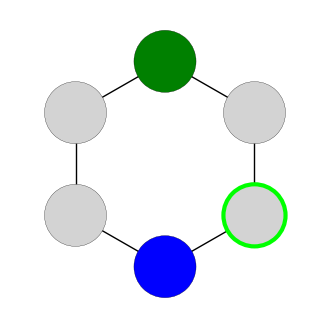

In [8]:
plot_circular_network(colors = ["green", "lightgrey", "lightgrey", "blue", "lightgrey", "lightgrey"], highlight_index = 2, figwidth = 4)

### Visualize Memory Filter Performance

In [ ]:
#| export
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.colors import ListedColormap
def memory_filter_performance(memory_data: dict[str,Any], 
                              observed_percepts: NDArray[np.int_],
                              colormap:list[str]|NDArray[np.str_]|None,      #must be valid default plt color strings
                              stationary_entropy: float|None = None,    #plotted as red hline
                              predictive_entropy: float|None = None,    #plotted as green hline
                              stacked: bool = False, 
                              bar_colors: list[str]|None = None):       #must be valid default plt color strings
    T = np.shape(observed_percepts)[0]
    fig = plt.figure(figsize=(8, 6))
    nrows, ncols = 2, 3  # Add extra row for colorbar
    
    # Adjust height ratios: small for colorbar, large for plots
    gs = GridSpec(nrows, ncols, 
                  height_ratios=[0.99, 0.01], 
                  width_ratios=[1, 8, 2],
                  figure=fig)
    
    axes_array = np.empty((1, ncols), dtype=object)  # only one plot row
    for j in range(ncols):
        axes_array[0, j] = fig.add_subplot(gs[0, j])  # use row 0 for plots
    

    
    #set up y axis labels
    yticks = np.array([1, T/2, T]) - 0.5
    ytick_labels = np.array([1,T/2,T])
    # Left plot (percept)
    plt.sca(axes_array[0,0])
    if colormap is None:
        plt.imshow(observed_percepts, aspect="auto", interpolation='nearest')
    else:
        # Convert color map
        cmap = ListedColormap(colormap)
        plt.imshow(observed_percepts, cmap=cmap, aspect="auto", interpolation='nearest',vmin=0, vmax=len(colormap)-1)
    axes_array[0,0].invert_yaxis()
    axes_array[0,0].set_xticks([])
    axes_array[0,0].set_yticks(yticks - 0.5),
    axes_array[0,0].set_yticklabels(ytick_labels),
    plt.title("Percept")
    plt.ylabel("Time Step")
    
    # Middle plot (Posterior Belief)
    im = plot_heatmap(
        memory_data["belief_posterior"], 
        ax=axes_array[0,1], 
        title="Posterior Belief",
        color="Oranges",
        yticks=yticks,
        ytick_labels=ytick_labels,
        xlabel="Hypothesis",
        ylabel = None,
        figsize=(8, 10),
        colorbar_kwargs=None  # remove automatic colorbar creation
    )
    
    # Right Plot (Surprise)
    plt.sca(axes_array[0,2])
    if stacked == True:
        surprisals = memory_data["surprise"]
        y = range(1,T+1)
        left = np.zeros(np.shape(surprisals)[0])
        for j in range(np.shape(surprisals)[1]):
            w = surprisals[:, j]
            plt.barh(
                y, w, left=left,
                color=bar_colors[j]
            )
            left += w
    else:    
        surprisals = np.sum(memory_data["surprise"], axis = 1)
        inf_surprise_mask = surprisals == -1 
        surprisals[inf_surprise_mask] = 40 #outside range of data
        plt.barh(y = range(1,T+1), width = np.ravel(surprisals), color = np.where(np.ravel(surprisals) == 40, "red", "mediumturquoise"))
    if stationary_entropy is not None:
        plt.axvline(x = stationary_entropy, color = "red", linestyle = "--", label = "Stationary Entropy")
    if predictive_entropy is not None:
        plt.axvline(x = predictive_entropy, color = "darkolivegreen", linestyle = "--", label = "Predictive Entropy")
    plt.title("Surprise", fontsize = 14)
    plt.ylim(0.5,T+0.5)
    plt.xticks(range(0, int(np.max(surprisals)+1), int(np.ceil(np.max(surprisals)/5))))
    plt.xlabel("bits")
    
    # Create a dedicated colorbar axis below the middle plot
    cax = fig.add_subplot(gs[1, 1])  # row 0, col 1
    
    # Create horizontal colorbar aligned with title, without shifting plot
    cbar = fig.colorbar(im, cax=cax, orientation='horizontal',shrink = 0.3, label = "Hypothesis Probability")
    cbar.ax.xaxis.set_label_position('bottom')
    plt.tight_layout()